## Tarea 3
Programa Experto en Inteligencia Artificial con Python  
ML2006 - Visualización e Interpretación de Datos  
Estudiante: Natalia Bonilla Villalobos.  
**Reglas de asociacion | plotly**

<a id="menu"></a>

# Menú
- [Ejercicio 1](#ej1)
- [Ejercicio 2](#ej2)

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import plotly.graph_objects as go
import plotly.express as px
%matplotlib inline

from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

import plotly.io as pio
pio.renderers.default = "notebook_connected"

<a id="ej1"></a>
# Ejercicio 1 
Para los siguientes ejercicios utilice la base de datos `Football.sqlite`, de la cual se obtuvo el dataframe que contiene las tablas de posiciones por liga y temporada.  

- a) [20 puntos] Construya un gráfico **interactivo** tipo **dumbbell** (combinación de puntos y líneas) para visualizar la tasa de goles anotados como local respecto al total de goles anotados, esto entre las temporadas 2008/2009 y 2015/2016 (solo esas dos temporadas), para las siguientes ligas: Bundesliga, Liga Española y la Liga Inglesa, es decir las tasas son por liga y temporada. Sea detallado con las etiquetas de los ejes, formatos, títulos, leyenda, etc., y adicionalmente muestre el dataframe usado como fuente del gráfico (puede usar como referencia este ejemplo https://plotly.com/python/dumbbell-plots/).
- b) [15 puntos] Muestre dos gráficos que detallen la tasa de rendimiento (puntos obtenidos/puntos totales posibles) para el ganador de cada temporada para las siguientes ligas: Bundesliga, Liga Española y la Liga Inglesa, utilice un gráfico estático con seaborn (muestre etiquetas resaltanto el ganador por temporada) y otro dinámico (defina el tipo y explique el porqudé de la selección). Sea detallado con las etiquetas de los ejes, formatos, títulos, leyenda, etc.
- c) [10 puntos] Construya un gráfico **interactivo** tipo **treemap** para comparar el total de goles anotados a favor por equipo para la Liga Española para la temporada 2014/2015; explique como preparó el dataframe previo a la visualización. Sea detallado con las etiquetas de los ejes, formatos, títulos, leyenda, etc. Agregue color a cada rectángulo del **treemap** en función a tres categorías de goles anotados: menos de 40, de 40 a 59, y 60 o más.

- d) [25 puntos] Construya un gráfico **interactivo** para mostrar los equipos con mejores tasas de ganes (top 5), y los equipos con peores tasas de pdérdidas (peores 5), no tome en cuenta los equipos de la liga Española ni de la liga Italiana. El gráfico resultante debe ser similar al mostrado a continuación.

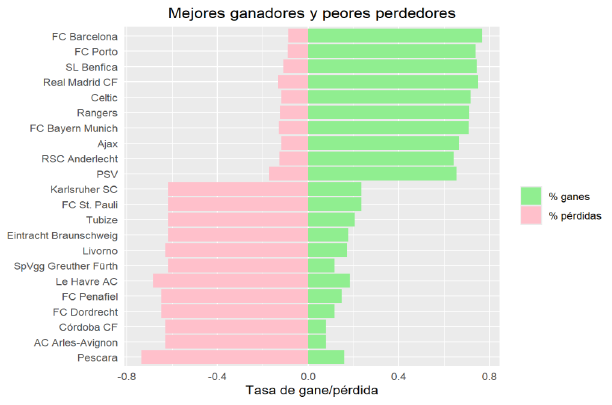   

- e) [5 puntos] Defina su propio análisis a realizar y construya un gráfico interactivo que dé solución al problema en cuestión. Explique el porqudé de la selección del tipo de gráfico, así como los resultados obtenidos.

[↑ Volver al Menú](#menu)


## Parte 1
- a) [20 puntos] Construya un gráfico **interactivo** tipo **dumbbell** (combinación de puntos y líneas) para visualizar la tasa de goles anotados como *local* respecto al total de goles anotados, esto entre las temporadas **2008/2009** y **2015/2016** (solo esas dos temporadas), para las siguientes ligas: **Bundesliga**, **Liga Española** y la **Liga Inglesa**, es decir las tasas son por liga y temporada.  

    Sea detallado con las etiquetas de los ejes, formatos, títulos, leyenda, etc., y adicionalmente muestre el dataframe usado como fuente del gráfico (puede usar como referencia este ejemplo https://plotly.com/python/dumbbell-plots/).

In [58]:
# Bundesliga, Liga Española y la Liga Inglesa
# Germany 1. Bundesliga, Spain LIGA BBVA, England Premier League
# temp_2008_2009
# temp_2015_2016

Tasa total = goles local / goles totales

In [59]:
conn = sqlite3.connect('../../w1/Football.sqlite')
filtro = pd.read_sql_query("""
select
    l.name as Liga,
    m.season as Temporada,
    m.home_team_goal as Goles_Local,
    m.away_team_goal as Goles_Visita
from Match m
join League l
    on m.league_id = l.id
""", conn)
conn.close()
filtro

,Liga,Temporada,Goles_Local,Goles_Visita
0,Belgium Jupiler League,2008/2009,1,1
1,Belgium Jupiler League,2008/2009,0,0
2,Belgium Jupiler League,2008/2009,0,3
3,Belgium Jupiler League,2008/2009,5,0
4,Belgium Jupiler League,2008/2009,1,3
...,...,...,...,...
25974,Switzerland Super League,2015/2016,1,0
25975,Switzerland Super League,2015/2016,1,2
25976,Switzerland Super League,2015/2016,2,0
25977,Switzerland Super League,2015/2016,0,0


In [60]:
ligas = [
    'Germany 1. Bundesliga',
    'Spain LIGA BBVA',
    'England Premier League'
]

temporadas = [
    '2008/2009',
    '2015/2016'
]

In [61]:
df_dumbbell = (
    filtro[
        filtro['Liga'].isin(ligas) &
        filtro['Temporada'].isin(temporadas)
    ].groupby(['Liga', 'Temporada']).agg(
        Goles_Local=('Goles_Local', 'sum'),
        Goles_Visita=('Goles_Visita', 'sum')
    ).reset_index()
)
df_dumbbell

,Liga,Temporada,Goles_Local,Goles_Visita
0,England Premier League,2008/2009,532,410
1,England Premier League,2015/2016,567,459
2,Germany 1. Bundesliga,2008/2009,520,374
3,Germany 1. Bundesliga,2015/2016,479,387
4,Spain LIGA BBVA,2008/2009,631,470
5,Spain LIGA BBVA,2015/2016,615,428


In [62]:
df_dumbbell['Goles_Totales'] = (df_dumbbell['Goles_Local'] + df_dumbbell['Goles_Visita'])
df_dumbbell['Tasa_Goles_Local'] = round((df_dumbbell['Goles_Local'] / df_dumbbell['Goles_Totales'])*100,2)
df_dumbbell['Tasa_Goles_Visita'] = round((df_dumbbell['Goles_Visita'] / df_dumbbell['Goles_Totales'])*100,2)
df_dumbbell


,Liga,Temporada,Goles_Local,Goles_Visita,Goles_Totales,Tasa_Goles_Local,Tasa_Goles_Visita
0,England Premier League,2008/2009,532,410,942,56.48,43.52
1,England Premier League,2015/2016,567,459,1026,55.26,44.74
2,Germany 1. Bundesliga,2008/2009,520,374,894,58.17,41.83
3,Germany 1. Bundesliga,2015/2016,479,387,866,55.31,44.69
4,Spain LIGA BBVA,2008/2009,631,470,1101,57.31,42.69
5,Spain LIGA BBVA,2015/2016,615,428,1043,58.96,41.04


In [63]:
# seleccionamos solo liga temprada y tasa local de goles
df_tasa = df_dumbbell[['Liga', 'Temporada', 'Tasa_Goles_Local']].reset_index(drop=True)
df_tasa

,Liga,Temporada,Tasa_Goles_Local
0,England Premier League,2008/2009,56.48
1,England Premier League,2015/2016,55.26
2,Germany 1. Bundesliga,2008/2009,58.17
3,Germany 1. Bundesliga,2015/2016,55.31
4,Spain LIGA BBVA,2008/2009,57.31
5,Spain LIGA BBVA,2015/2016,58.96


In [64]:
# pivot para tner la tasa por liga x temporada
df_tasa_pivot = (
    df_tasa.pivot(
    index='Liga',
    columns='Temporada',
    values=['Tasa_Goles_Local'])
    ).reset_index()

# para aplanar el df
df_tasa_pivot.columns = [
    'Liga',
    '2008/2009',
    '2015/2016'
]

In [65]:
fig = go.Figure()

for idx, row in df_tasa_pivot.iterrows():

    # settings de la linea
    fig.add_trace(
        go.Scatter(
            x=[row['2008/2009'], row['2015/2016']],
            y=[row['Liga'], row['Liga']],
            mode='lines',
            showlegend=False,
            marker=dict(
                color="grey",
                # symbol="arrow",
                # size=16,
                # angleref="previous",
                # standoff=8
            )
        )
    )

    # Temporada 2008/2009
    fig.add_trace(
        go.Scatter(
            x=[row['2008/2009']],
            y=[row['Liga']],
            mode='markers+text',
            marker=dict(
                color='green',
                size=10
            ),
            text=[f"{row['2008/2009']:.1f}%"],
            textposition='top center',
            name='2008/2009',
            showlegend=(idx == 0) # solo se muestra leyenda para el primer punto de cada temporada
        )
    )

    # Temporada 2015/2016
    fig.add_trace(
        go.Scatter(
            x=[row['2015/2016']],
            y=[row['Liga']],
            mode='markers+text',
            marker=dict(
                color='blue',
                size=10
            ),
            text=[f"{row['2015/2016']:.1f}%"],
            textposition='top center',
            name='2015/2016',
            showlegend=(idx == 0) # solo se muestra leyenda para el primer punto de cada temporada
        )
    )

fig.update_layout(
    title=dict(text=f"Tasa de Goles de Locales respecto al total de goles<br>Temporadas 2008/2009 vs 2015/2016", 
               x=0.5,  # centrar el titulo horizontalmente
            #  y=0.95, # ajustar la posicion vertical del titulo
            ),
    xaxis_title='Tasa Goles de Local (%)',
    template='plotly_white',
    height=450,
    legend_itemclick=False
)

fig.show()

df_tasa_pivot

,Liga,2008/2009,2015/2016
0,England Premier League,56.48,55.26
1,Germany 1. Bundesliga,58.17,55.31
2,Spain LIGA BBVA,57.31,58.96


## Parte 2
- b) [15 puntos] Muestre dos gráficos que detallen la tasa de rendimiento (puntos obtenidos/puntos totales posibles) para el ganador de cada temporada para las siguientes ligas: Bundesliga, Liga Española y la Liga Inglesa, utilice un gráfico estático con seaborn (muestre etiquetas resaltanto el ganador por temporada) y otro dinámico (defina el tipo y explique el porqudé de la selección). Sea detallado con las etiquetas de los ejes, formatos, títulos, leyenda, etc.

In [66]:
conn = sqlite3.connect('../../w1/Football.sqlite')
football = pd.read_sql_query(
    """
    select
    Liga, Temporada, Equipo, Equipo_longName,
    sum(Total_Puntos) as Total_Puntos,
    sum(Partidos_Jugados) as Partidos_Jugados,
    sum(Partidos_Empatados) as Partidos_Empatados,
    sum(Partidos_Perdidos) as Partidos_Perdidos,
    sum(GF) as GF,
    sum(GC) as GC,
    sum(GF) - sum(GC) as Diferencia_Goles
from(
    -- Local
    select l.name as Liga,
           m.season as Temporada,
           t.team_short_name as Equipo,
           t.team_long_name as Equipo_longName,
           case
               when m.home_team_goal > m.away_team_goal then 3
               when m.home_team_goal = m.away_team_goal then 1
               else 0
           end as Total_Puntos,
           1 as Partidos_Jugados,
           case when m.home_team_goal = m.away_team_goal then 1 else 0 end as Partidos_Empatados,
           case when m.home_team_goal < m.away_team_goal then 1 else 0 end as Partidos_Perdidos,
           m.home_team_goal as GF,
           m.away_team_goal as GC
    from Match m
    inner join (select distinct team_api_id, team_short_name, team_long_name from Team) t
        on m.home_team_api_id = t.team_api_id
    inner join League l
        on m.league_id = l.id

    UNION ALL

    -- Visitante
    select l.name as Liga,
           m.season as Temporada,
           t.team_short_name as Equipo,
           t.team_long_name as Equipo_longName,
           case
               when m.home_team_goal < m.away_team_goal then 3
               when m.home_team_goal = m.away_team_goal then 1
               else 0
           end as Total_Puntos,
           1 as Partidos_Jugados,
           case when m.home_team_goal = m.away_team_goal then 1 else 0 end as Partidos_Empatados,
           case when m.home_team_goal > m.away_team_goal then 1 else 0 end as Partidos_Perdidos,
           m.away_team_goal as GF,
           m.home_team_goal as GC
    from Match m
    inner join (select distinct team_api_id, team_short_name, team_long_name from Team) t
        on m.away_team_api_id = t.team_api_id
    inner join League l
        on m.league_id = l.id
) as tabla
group by
        Liga,
        Temporada,
        Equipo,
        Equipo_longName
    """
    , conn)
conn.close()
football

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles
0,Belgium Jupiler League,2008/2009,AND,RSC Anderlecht,77,34,5,5,75,30,45
1,Belgium Jupiler League,2008/2009,BAC,Beerschot AC,42,34,9,14,44,42,2
2,Belgium Jupiler League,2008/2009,CEB,KSV Cercle Brugge,47,34,5,15,48,53,-5
3,Belgium Jupiler League,2008/2009,CHA,Sporting Charleroi,43,34,7,15,43,48,-5
4,Belgium Jupiler League,2008/2009,CLB,Club Brugge KV,59,34,5,11,59,50,9
...,...,...,...,...,...,...,...,...,...,...,...
1476,Switzerland Super League,2015/2016,SIO,FC Sion,50,36,8,14,52,49,3
1477,Switzerland Super League,2015/2016,THU,FC Thun,41,36,11,15,45,54,-9
1478,Switzerland Super League,2015/2016,VAD,FC Vaduz,36,36,15,14,44,60,-16
1479,Switzerland Super League,2015/2016,YB,BSC Young Boys,69,36,9,7,78,47,31


In [67]:
ligas_rendimiento = football[
    football['Liga'].isin(['England Premier League', 'Germany 1. Bundesliga', 'Spain LIGA BBVA'])
]

In [68]:
campeones = (
    ligas_rendimiento.sort_values(
        ['Liga', 'Temporada', 'Total_Puntos', 'Diferencia_Goles', 'GF'],
        ascending=[True, True, False, False, False])
        .groupby(['Liga', 'Temporada'])
        .head(1)
        .reset_index(drop=True)
)
campeones.head(5)

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles
0,England Premier League,2008/2009,MUN,Manchester United,90,38,6,4,68,24,44
1,England Premier League,2009/2010,CHE,Chelsea,86,38,5,6,103,32,71
2,England Premier League,2010/2011,MUN,Manchester United,80,38,11,4,78,37,41
3,England Premier League,2011/2012,MCI,Manchester City,89,38,5,5,93,29,64
4,England Premier League,2012/2013,MUN,Manchester United,89,38,5,5,86,43,43


In [69]:
campeones = (
    ligas_rendimiento
    .sort_values(
        ['Liga','Temporada','Total_Puntos','Diferencia_Goles','GF'],
        ascending=[True, True, False, False, False]
    )
    .groupby(['Liga','Temporada'])
    .head(1)
    .reset_index(drop=True)
)

campeones[['Liga','Temporada','Equipo_longName','Total_Puntos']]

,Liga,Temporada,Equipo_longName,Total_Puntos
0,England Premier League,2008/2009,Manchester United,90
1,England Premier League,2009/2010,Chelsea,86
2,England Premier League,2010/2011,Manchester United,80
3,England Premier League,2011/2012,Manchester City,89
4,England Premier League,2012/2013,Manchester United,89
5,England Premier League,2013/2014,Manchester City,86
6,England Premier League,2014/2015,Chelsea,87
7,England Premier League,2015/2016,Leicester City,81
8,Germany 1. Bundesliga,2008/2009,VfL Wolfsburg,69
9,Germany 1. Bundesliga,2009/2010,FC Bayern Munich,70


In [70]:
rendimiento = campeones.copy()
rendimiento['puntos_max'] = rendimiento['Partidos_Jugados'] * 3
rendimiento['Rendimiento'] = round(rendimiento['Total_Puntos'] / rendimiento['puntos_max'] * 100, 2)

rendimiento  = rendimiento[['Liga', 'Temporada', 'Equipo', 'Equipo_longName', 'Total_Puntos', 'Rendimiento']].sort_values(by='Rendimiento', ascending=False)
rendimiento

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Rendimiento
12,Germany 1. Bundesliga,2012/2013,BMU,FC Bayern Munich,91,89.22
13,Germany 1. Bundesliga,2013/2014,BMU,FC Bayern Munich,90,88.24
20,Spain LIGA BBVA,2012/2013,BAR,FC Barcelona,100,87.72
19,Spain LIGA BBVA,2011/2012,REA,Real Madrid CF,100,87.72
17,Spain LIGA BBVA,2009/2010,BAR,FC Barcelona,99,86.84
15,Germany 1. Bundesliga,2015/2016,BMU,FC Bayern Munich,88,86.27
18,Spain LIGA BBVA,2010/2011,BAR,FC Barcelona,96,84.21
22,Spain LIGA BBVA,2014/2015,BAR,FC Barcelona,94,82.46
23,Spain LIGA BBVA,2015/2016,BAR,FC Barcelona,91,79.82
11,Germany 1. Bundesliga,2011/2012,DOR,Borussia Dortmund,81,79.41


In [71]:
# rendimiento[['Liga',
#              'Temporada',
#              'Equipo_longName',
#              'Rendimiento']]

orden_temporadas = [
    '2008/2009',
    '2009/2010',
    '2010/2011',
    '2011/2012',
    '2012/2013',
    '2013/2014',
    '2014/2015',
    '2015/2016'
]

rendimiento['Temporada'] = pd.Categorical(
    rendimiento['Temporada'],
    categories=orden_temporadas,
    ordered=True
)

rendimiento = rendimiento.sort_values(['Liga', 'Temporada'])

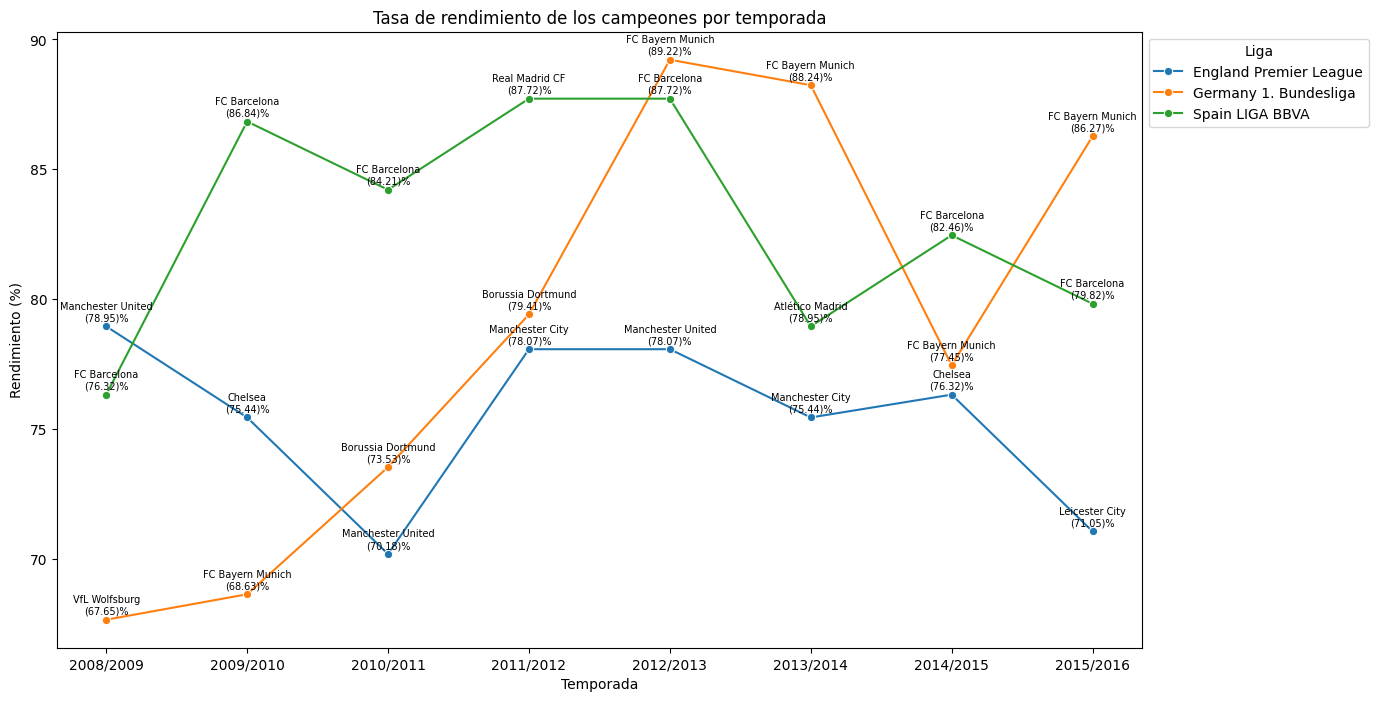

In [72]:
plt.figure(figsize=(14,8))
ax = sns.lineplot(
    data=rendimiento,
    x='Temporada',
    y='Rendimiento',
    hue='Liga',
    marker='o'
)

plt.title('Tasa de rendimiento de los campeones por temporada')
plt.ylabel('Rendimiento (%)')
plt.xlabel('Temporada')

for idx, row in rendimiento.iterrows():

    ax.annotate(
        text=f"{row['Equipo_longName']}\n({row['Rendimiento']})%",
        xy=(row['Temporada'],
            row['Rendimiento']),
        xytext=(0,4),
        textcoords='offset points',
        ha='center',
        fontsize=7
    )
    
ax.legend(title="Liga", fontsize=2, title_fontsize=10)
sns.move_legend(ax, "upper left",  bbox_to_anchor=(1, 1))

# plt.xticks(rotation=45)

plt.show()

In [73]:
fig = go.Figure()

fig = px.line(
    rendimiento,
    x='Temporada',
    y='Rendimiento',
    color='Liga',
    markers=True,
    # hover_data={
    #     'Equipo_longName': True,
    #     'Rendimiento': ':.2f',
    #     'Liga': False
    # }
    custom_data=['Equipo_longName']
    
)

fig.update_traces(
    hovertemplate=
    "<b>%{customdata[0]}</b><br>" +
    "Rendimiento: %{y:.2f}%<br>" +
    "Temporada: %{x}<extra></extra>"
    # text=rendimiento['Equipo_longName']
    # textposition='top center'
)

fig.update_layout(
    xaxis_title='Temporada',
    yaxis_title='Rendimiento (%)',
    legend_title='Liga',
    template='plotly_white',
    # height=300,
    title = dict(text="Tasa de Rendimiento de los campeones<br>Temporadas del 2008/2009 al 2015/2016", x=0.5),
)

fig.show()

Para aprovechar la línea del tiempo el gráfico que se decidió usar es el grafico de líneas, porque es probablemente el mejor grafico para representar el rendimiento en un periodo de 8 años (temporadas del 2008/2019 al 2015/2016) de los equipos campiones.

## Parte 3

- c) [10 puntos] Construya un gráfico interactivo tipo treemap para comparar el *total de goles anotados a favor* por equipo para la **Liga Española** para la temporada 2014/2015; explique como preparó el dataframe previo a la visualización. Sea detallado con las etiquetas de los ejes, formatos, títulos, leyenda, etc. Agregue color a cada rectángulo del treemap en función a tres categorías de goles anotados: menos de 40, de 40 a 59, y 60 o más.

In [74]:
spain_total_goles_14_15 = football[
    (football['Liga'] == 'Spain LIGA BBVA') &
    (football['Temporada'] == '2014/2015')
][['Equipo_longName', 'GF']].reset_index(drop=True).copy()
spain_total_goles_14_15

,Equipo_longName,GF
0,UD Almería,35
1,Atlético Madrid,67
2,FC Barcelona,110
3,Athletic Club de Bilbao,42
4,RC Celta de Vigo,47
5,Córdoba CF,22
6,RC Deportivo de La Coruña,35
7,SD Eibar,34
8,Elche CF,35
9,RCD Espanyol,47


In [75]:
spain_total_goles_14_15['Categoria'] = np.where(
    spain_total_goles_14_15['GF'] < 40,
    'Menos de 40 goles',
    np.where(
        spain_total_goles_14_15['GF'] < 60,
        'De 40 a 59 goles',
        '60 goles o más'
    )
)

spain_total_goles_14_15.sort_values('GF', ascending=False)

,Equipo_longName,GF,Categoria
15,Real Madrid CF,118,60 goles o más
2,FC Barcelona,110,60 goles o más
16,Sevilla FC,71,60 goles o más
18,Valencia CF,70,60 goles o más
1,Atlético Madrid,67,60 goles o más
19,Villarreal CF,48,De 40 a 59 goles
4,RC Celta de Vigo,47,De 40 a 59 goles
9,RCD Espanyol,47,De 40 a 59 goles
14,Rayo Vallecano,46,De 40 a 59 goles
17,Real Sociedad,44,De 40 a 59 goles


In [76]:
fig = px.treemap(
    spain_total_goles_14_15,
    path=['Categoria', 'Equipo_longName'],
    values='GF',
    color='Categoria',
    hover_data=['GF'],
    color_discrete_map={
        'Menos de 40 goles': 'darkred',
        'De 40 a 59 goles': 'darkorange',
        '60 goles o más': 'darkgreen'
    }
)

fig.update_layout(
    title=dict(text="Goles a favor por categoría<br>'Spain LIGA BBVA' - Temporada 2014/2015", x=0.5, y=0.92),
    # template='plotly_white',
    # legend_title='Categoría de Goles',
)

fig.update_traces(
    # textinfo='value'
    hovertemplate=
    "<b>%{label}</b><br>" +
    "Goles a Favor: %{value}<br>" +
    "Categoria: %{parent}<extra></extra>"
    # text=rendimiento['Equipo_longName']
    # textposition='top center'
)

fig.show()

Se filta usando el dataframe `football` y se genera una nueva variable con el nombre `spain_total_goles_14_15` el cual conseva los equipos de 'Spain LIGA BBVA' y la Temporada 2014/2015 y se selecciona la variable 'GF' (Goles a Favor). Seguidamente se usa un `np.where` para clasificar a los equipos en 3 Categorías ('Menos de 40 goles', 'De 40 a 59 goles' y '60 goles o más'), para poteriormente representar `spain_total_goles_14_15` con el gráfico de treemap.


## Parte 4
- d) [25 puntos] Construya un gráfico interactivo para mostrar los equipos con mejores tasas de ganes (top 5), y los equipos con peores tasas de pérdidas (peores 5), no tome en cuenta los equipos de la liga Española ni de la liga Italiana. El gráfico resultante debe ser similar al mostrado a continuación.

In [77]:
rendimiento_ligas = football.copy()
rendimiento_ligas = rendimiento_ligas[
    ~(rendimiento_ligas['Liga'].isin(['Spain LIGA BBVA', 'Italy Serie A']))
]

In [78]:
rendimiento_ligas['Partidos_Ganados'] = (rendimiento_ligas['Partidos_Jugados'] - rendimiento_ligas['Partidos_Empatados'] - rendimiento_ligas['Partidos_Perdidos'])
rendimiento_ligas['Tasa_Ganados'] = round((rendimiento_ligas['Partidos_Ganados'] / rendimiento_ligas['Partidos_Jugados'])*100,2)
rendimiento_ligas.sample(5)

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,Partidos_Ganados,Tasa_Ganados
1439,Switzerland Super League,2011/2012,YB,BSC Young Boys,51,34,12,9,52,38,14,13,38.24
1021,Portugal Liga ZON Sagres,2008/2009,MAR,CS Marítimo,37,30,10,11,35,36,-1,9,30.00
229,England Premier League,2013/2014,NOR,Norwich City,33,38,9,21,28,62,-34,8,21.05
486,Germany 1. Bundesliga,2010/2011,S04,FC Schalke 04,40,34,7,16,38,44,-6,11,32.35
1158,Scotland Premier League,2009/2010,CEL,Celtic,81,38,6,7,75,39,36,25,65.79


In [79]:
rendimiento_ligas['Tasa_Perdidos'] = round((rendimiento_ligas['Partidos_Perdidos'] / rendimiento_ligas['Partidos_Jugados'])*100,2)
rendimiento_ligas.sample(5)

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,Partidos_Ganados,Tasa_Ganados,Tasa_Perdidos
312,France Ligue 1,2009/2010,PSG,Paris Saint-Germain,47,38,11,15,50,46,4,12,31.58,39.47
421,France Ligue 1,2015/2016,ETI,AS Saint-Étienne,58,38,7,14,42,37,5,17,44.74,36.84
279,France Ligue 1,2008/2009,CAE,SM Caen,37,38,13,17,42,49,-7,8,21.05,44.74
1128,Portugal Liga ZON Sagres,2015/2016,ARO,FC Arouca,54,34,15,6,47,38,9,13,38.24,17.65
192,England Premier League,2011/2012,SWA,Swansea City,47,38,11,15,44,51,-7,12,31.58,39.47


In [80]:
top_mejores5 = rendimiento_ligas.sort_values('Tasa_Ganados', ascending=False).head(5)
top_peores5 = rendimiento_ligas.sort_values('Tasa_Perdidos', ascending=False).head(5)

In [81]:
top_mejores5[
    top_mejores5['Equipo_longName'] == 'FC Bayern Munich'
]

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,Partidos_Ganados,Tasa_Ganados,Tasa_Perdidos
528,Germany 1. Bundesliga,2013/2014,BMU,FC Bayern Munich,90,34,3,2,94,23,71,29,85.29,5.88
510,Germany 1. Bundesliga,2012/2013,BMU,FC Bayern Munich,91,34,4,1,98,18,80,29,85.29,2.94


In [82]:
chart = pd.concat([
    top_mejores5,
    top_peores5
]).reset_index(drop=True)

In [83]:
chart['Perdidas_Neg'] = (
    chart['Tasa_Perdidos'] * -1
)

In [84]:
fig = go.Figure()
fig.add_trace(
    go.Bar(
        y=chart['Equipo_longName'],
        x=chart['Perdidas_Neg'],
        name='% Partidos Perdidos',
        orientation='h'
    )
)

fig.add_trace(
    go.Bar(
        y=chart['Equipo_longName'],
        x=chart['Tasa_Ganados'],
        name='% Partidos Ganados',
        orientation='h'
    )
)

fig.update_layout(
    title=dict(text="Top 5 de mejores y Top 5 de peores<br>según la tasa de ganes/perdidas", x=0.5, y=0.92),
    # title='Mejores ganadores y peores perdedores',
    xaxis_title='Tasa de Ganados/Perdidos',
    # yaxis_title='Equipo',
    barmode='overlay', # para que salgan en la misma linea
    # template='plotly_white',
    plot_bgcolor="white"
)

fig.update_traces(
    hovertemplate=
    "<b>%{label}</b><br>"
    "%{value}%"
)

fig.show()

## Parte 5

- e) [5 puntos] Defina su propio análisis a realizar y construya un gráfico interactivo que dé solución al problema en cuestión. Explique el porqué de la selección del tipo de gráfico, así como los resultados obtenidos.

In [85]:
football['Liga'].unique()

array(['Belgium Jupiler League', 'England Premier League',
       'France Ligue 1', 'Germany 1. Bundesliga', 'Italy Serie A',
       'Netherlands Eredivisie', 'Poland Ekstraklasa',
       'Portugal Liga ZON Sagres', 'Scotland Premier League',
       'Spain LIGA BBVA', 'Switzerland Super League'], dtype=object)

In [86]:
evolucion_defensiva = football.copy()
evolucion_defensiva = evolucion_defensiva[
    evolucion_defensiva['Liga'].isin(['Belgium Jupiler League'])
]
evolucion_defensiva

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles
0,Belgium Jupiler League,2008/2009,AND,RSC Anderlecht,77,34,5,5,75,30,45
1,Belgium Jupiler League,2008/2009,BAC,Beerschot AC,42,34,9,14,44,42,2
2,Belgium Jupiler League,2008/2009,CEB,KSV Cercle Brugge,47,34,5,15,48,53,-5
3,Belgium Jupiler League,2008/2009,CHA,Sporting Charleroi,43,34,7,15,43,48,-5
4,Belgium Jupiler League,2008/2009,CLB,Club Brugge KV,59,34,5,11,59,50,9
...,...,...,...,...,...,...,...,...,...,...,...
112,Belgium Jupiler League,2015/2016,STL,Standard de Liège,41,30,5,13,41,51,-10
113,Belgium Jupiler League,2015/2016,STT,Sint-Truidense VV,30,30,6,16,28,47,-19
114,Belgium Jupiler League,2015/2016,WAA,Waasland-Beveren,33,30,6,15,40,57,-17
115,Belgium Jupiler League,2015/2016,WES,KVC Westerlo,30,30,9,14,35,59,-24


In [87]:
evolucion_defensiva['GC_x_Partido'] = (
    evolucion_defensiva['GC']/evolucion_defensiva['Partidos_Jugados']
)
evolucion_defensiva.head(5)

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,GC_x_Partido
0,Belgium Jupiler League,2008/2009,AND,RSC Anderlecht,77,34,5,5,75,30,45,0.882353
1,Belgium Jupiler League,2008/2009,BAC,Beerschot AC,42,34,9,14,44,42,2,1.235294
2,Belgium Jupiler League,2008/2009,CEB,KSV Cercle Brugge,47,34,5,15,48,53,-5,1.558824
3,Belgium Jupiler League,2008/2009,CHA,Sporting Charleroi,43,34,7,15,43,48,-5,1.411765
4,Belgium Jupiler League,2008/2009,CLB,Club Brugge KV,59,34,5,11,59,50,9,1.470588


In [88]:
len(evolucion_defensiva['Equipo_longName'].unique())

24

In [89]:
evolucion_defensiva['GC_x_Partido'].max()


2.264705882352941

In [90]:
ranking = (
    evolucion_defensiva.groupby('Equipo_longName')['GC_x_Partido'].mean().sort_values(ascending=True).head(10).index
)

In [91]:
top10_historicos = evolucion_defensiva[
    evolucion_defensiva['Equipo_longName'].isin(ranking)
].copy()

top10_historicos.head()

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,GC_x_Partido
0,Belgium Jupiler League,2008/2009,AND,RSC Anderlecht,77,34,5,5,75,30,45,0.882353
4,Belgium Jupiler League,2008/2009,CLB,Club Brugge KV,59,34,5,11,59,50,9,1.470588
6,Belgium Jupiler League,2008/2009,GEN,KAA Gent,59,34,8,9,67,42,25,1.235294
7,Belgium Jupiler League,2008/2009,GEN,KRC Genk,50,34,5,14,48,51,-3,1.500000
8,Belgium Jupiler League,2008/2009,KOR,KV Kortrijk,38,34,11,14,37,55,-18,1.617647


In [92]:
orden_equipos = (
    top10_historicos.groupby('Equipo_longName')['GC_x_Partido'].mean().sort_values().index.tolist()
)

In [93]:
top10_historicos['Equipo_longName'].unique()

array(['RSC Anderlecht', 'Club Brugge KV', 'KAA Gent', 'KRC Genk',
       'KV Kortrijk', 'Sporting Lokeren', 'KV Mechelen',
       'Standard de Liège', 'SV Zulte-Waregem', 'KV Oostende'],
      dtype=object)

In [94]:
import plotly.express as px

fig = px.bar(
    top10_historicos,
    x='GC_x_Partido',
    y='Equipo_longName',
    orientation='h',
    animation_frame='Temporada',
    color='Equipo_longName',
    category_orders={'Equipo_longName': orden_equipos},
    labels={
        'GC_x_Partido':'Goles recibidos por partido',
        'Equipo_longName':'Equipos'
    },
    range_x=[
        0, top10_historicos['GC_x_Partido'].max() + 0.1
    ]
)

fig.update_layout(
    title=dict(
        text='Evolución de los equipos que reciben menos goles por partido por temporada<br>Belgium Jupiler League',
        x=0.5
    ),
    xaxis_title='Promedio de goles recibidos por partido',
    yaxis_title='',
    template='plotly_white',
    height=500
)

fig.update_traces(
    # text=top10_historicos['GC_x_Partido'].round(2),
    # texttemplate='%{text}',
    # textposition='outside',
    hovertemplate=
    '<b>%{y}</b><br>' +
    'GC por partido: %{x:.2f}<br>' +
    '<extra></extra>'
)


fig.layout.sliders[0].currentvalue.prefix = 'Temporada: '
fig.layout.sliders[0]['transition']['duration'] = 2500
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 2500
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['redraw'] = False
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 2500
fig.layout.updatemenus[0].buttons[0].args[1]['transition']['easing'] = 'quade'
fig.show()

In [95]:
evolucion_defensiva[
    evolucion_defensiva['Temporada'] == '2013/2014'
].sort_values('GC_x_Partido')

,Liga,Temporada,Equipo,Equipo_longName,Total_Puntos,Partidos_Jugados,Partidos_Empatados,Partidos_Perdidos,GF,GC,Diferencia_Goles,GC_x_Partido
83,Belgium Jupiler League,2013/2014,OOS,KV Oostende,14,6,2,0,7,1,6,0.166667
81,Belgium Jupiler League,2013/2014,GEN,KAA Gent,10,6,1,2,11,6,5,1.000000
84,Belgium Jupiler League,2013/2014,WAA,Waasland-Beveren,4,6,1,4,7,11,-4,1.833333
82,Belgium Jupiler League,2013/2014,LIE,Lierse SK,6,6,0,4,5,12,-7,2.000000


Con un gráfico de barras animado se cuenta la historia de la evolución de los diez equipos que en promedio menos goles recibieron por partido desde las temporadas del 2008/2019 hasta el 2015/2016, de la Liga 'Belgium Jupiler League'. Además, mientras que otros aparecen únicamente en determinadas temporadas debido a cambios en su rendimiento o permanencia en la competición, el equipo 'RSC Anderlecht' es uno de los equipos menos goleados, estando fuera en la temporada 2013/2014, además se observa que en la temporada 2013/2014 otro equipo logró registrar un mejor desempeño defensivo, evidenciando que el liderazgo en esta métrica puede variar entre temporadas a pesar de la consistencia histórica de algunos equipos. Sin embargo, es importante considerar que algunos equipos disputaron una menor cantidad de partidos en ciertas temporadas, por lo que sus promedios de goles recibidos por partido podrían verse favorecidos por una muestra más reducida. Por esta razón, los resultados deben interpretarse como una comparación descriptiva del rendimiento defensivo de los equipos a través del tiempo.


<a id="ej2"></a>
# Ejercicio 2

Utilizando el archivo Titanic.csv visto en clase:  

- a) [5 puntos] Modifique el dataframe para codificar tres nuevas variables 
    - Un grupo de edad de la siguiente manera: mayor o igual a 65 (Adultos mayores), mayor o igual a 18 (Adultos), mayor o igual a 12 (Adolescentes), el resto ‘Niños’.
    - Un indicador si viajaban con los padres: Si Parch = 0, ‘No’, de lo contrario ‘Si’ 
    - Un indicador si viajaban con hermanos: Si SibSp = 0, ‘No’, de lo contrario ‘Si’
    Además de las nuevas variables, siga tomando en cuenta la clase (Pclass), g´enero (Sex), puerto de embarque (Embarked) y el indicador si sobrevivió o no (Survived).  
    Muestre los primero 20 registros del dataframe resultante.
- b) [10 puntos] Genere un modelo de reglas de asociación (tratando de identificar si sobrevivieron o no) con parámetros de soporte=2% y confianza=90%. Inspeccione y explique las primeras 4 reglas según lift.  

- c) [10 puntos] Construya un(os) gráfico(s) (defina el tipo y explique el porqu´e de la selección) para visualizar dichas reglas.

[↑ Volver al Menú](#menu)

In [96]:
titanic = pd.read_csv('../titanic.csv', index_col=0)
titanic

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,1,Muere,Tercera Clase,"Braund, Mr. Owen Harris",Hombre,22.0,1,0,A/5 21171,7.2500,NaN,S
2,2,Sobrevive,Primera Clase,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",Mujer,38.0,1,0,PC 17599,71.2833,C85,C
3,3,Sobrevive,Tercera Clase,"Heikkinen, Miss. Laina",Mujer,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,4,Sobrevive,Primera Clase,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mujer,35.0,1,0,113803,53.1000,C123,S
5,5,Muere,Tercera Clase,"Allen, Mr. William Henry",Hombre,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
1301,1301,Sobrevive,Tercera Clase,"Peacock, Miss. Treasteall",Mujer,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S
1303,1303,Sobrevive,Primera Clase,"Minahan, Mrs. William Edward (Lillian E Thorpe)",Mujer,37.0,1,0,19928,90.0000,C78,Q
1304,1304,Sobrevive,Tercera Clase,"Henriksson, Miss. Jenny Lovisa",Mujer,28.0,0,0,347086,7.7750,NaN,S
1306,1306,Sobrevive,Primera Clase,"Oliva y Ocana, Dona. Fermina",Mujer,39.0,0,0,PC 17758,108.9000,C105,C


## Parte 1

- a) [5 puntos] Modifique el dataframe para codificar tres nuevas variables 
    - Un grupo de edad de la siguiente manera: mayor o igual a 65 (Adultos mayores), mayor o igual a 18 (Adultos), mayor o igual a 12 (Adolescentes), el resto ‘Niños’.
    - Un indicador si viajaban con los padres: Si Parch = 0, ‘No’, de lo contrario ‘Si’ 
    - Un indicador si viajaban con hermanos: Si SibSp = 0, ‘No’, de lo contrario ‘Si’  
    
    Además de las nuevas variables, siga tomando en cuenta la clase (Pclass), género (Sex), puerto de embarque (Embarked) y el indicador si sobrevivió o no (Survived).   
    Muestre los primero 20 registros del dataframe resultante.

In [97]:
datos = titanic.copy()
datos['Grupo_Edad'] = (
    #    lambda x: [valor_si_verdadero] if [condicion] else (if [condicion] else [valor_si_falso])
    datos['Age'].apply(lambda x: 'Adulto Mayor' if x >= 65  else ('Adulto' if x >= 18 else ('Adolescente' if x >= 12 else 'Niños')))
)

datos

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Grupo_Edad
1,1,Muere,Tercera Clase,"Braund, Mr. Owen Harris",Hombre,22.0,1,0,A/5 21171,7.2500,NaN,S,Adulto
2,2,Sobrevive,Primera Clase,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",Mujer,38.0,1,0,PC 17599,71.2833,C85,C,Adulto
3,3,Sobrevive,Tercera Clase,"Heikkinen, Miss. Laina",Mujer,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adulto
4,4,Sobrevive,Primera Clase,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mujer,35.0,1,0,113803,53.1000,C123,S,Adulto
5,5,Muere,Tercera Clase,"Allen, Mr. William Henry",Hombre,35.0,0,0,373450,8.0500,NaN,S,Adulto
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1301,1301,Sobrevive,Tercera Clase,"Peacock, Miss. Treasteall",Mujer,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,Niños
1303,1303,Sobrevive,Primera Clase,"Minahan, Mrs. William Edward (Lillian E Thorpe)",Mujer,37.0,1,0,19928,90.0000,C78,Q,Adulto
1304,1304,Sobrevive,Tercera Clase,"Henriksson, Miss. Jenny Lovisa",Mujer,28.0,0,0,347086,7.7750,NaN,S,Adulto
1306,1306,Sobrevive,Primera Clase,"Oliva y Ocana, Dona. Fermina",Mujer,39.0,0,0,PC 17758,108.9000,C105,C,Adulto


In [98]:
# datos['con_padres'] = (datos['Parch'].apply(lambda x: 'No' if x == 0 else 'Si')) -> otra forma de hacerlo con np.where
datos['Con_Padres'] = np.where(
    (datos['Parch'] == 0), 'No', 'Si'
    )
   
#   lambda x: [valor_si_verdadero] if [condicion] else (if [condicion] else [valor_si_falso])
datos['Con_Hermanos'] = (datos['SibSp'].apply(lambda x: 'No' if x == 0 else 'Si'))

datos

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Grupo_Edad,Con_Padres,Con_Hermanos
1,1,Muere,Tercera Clase,"Braund, Mr. Owen Harris",Hombre,22.0,1,0,A/5 21171,7.2500,NaN,S,Adulto,No,Si
2,2,Sobrevive,Primera Clase,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",Mujer,38.0,1,0,PC 17599,71.2833,C85,C,Adulto,No,Si
3,3,Sobrevive,Tercera Clase,"Heikkinen, Miss. Laina",Mujer,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Adulto,No,No
4,4,Sobrevive,Primera Clase,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mujer,35.0,1,0,113803,53.1000,C123,S,Adulto,No,Si
5,5,Muere,Tercera Clase,"Allen, Mr. William Henry",Hombre,35.0,0,0,373450,8.0500,NaN,S,Adulto,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1301,1301,Sobrevive,Tercera Clase,"Peacock, Miss. Treasteall",Mujer,3.0,1,1,SOTON/O.Q. 3101315,13.7750,NaN,S,Niños,Si,Si
1303,1303,Sobrevive,Primera Clase,"Minahan, Mrs. William Edward (Lillian E Thorpe)",Mujer,37.0,1,0,19928,90.0000,C78,Q,Adulto,No,Si
1304,1304,Sobrevive,Tercera Clase,"Henriksson, Miss. Jenny Lovisa",Mujer,28.0,0,0,347086,7.7750,NaN,S,Adulto,No,No
1306,1306,Sobrevive,Primera Clase,"Oliva y Ocana, Dona. Fermina",Mujer,39.0,0,0,PC 17758,108.9000,C105,C,Adulto,No,No


In [99]:
datos.drop(['Name', 'Ticket', 'Cabin', 'PassengerId', 'SibSp', 'Parch', 'Fare', 'Age'], axis=1, inplace=True)
for col in datos.columns:
    datos[col] = datos[col].astype("category")

datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1045 entries, 1 to 1307
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Survived      1045 non-null   category
 1   Pclass        1045 non-null   category
 2   Sex           1045 non-null   category
 3   Embarked      1043 non-null   category
 4   Grupo_Edad    1045 non-null   category
 5   Con_Padres    1045 non-null   category
 6   Con_Hermanos  1045 non-null   category
dtypes: category(7)
memory usage: 16.2 KB


In [100]:
moda = datos['Embarked'].mode()[0]
datos = datos.fillna({'Embarked': moda})
datos.isnull().sum()

Survived        0
Pclass          0
Sex             0
Embarked        0
Grupo_Edad      0
Con_Padres      0
Con_Hermanos    0
dtype: int64

In [101]:
datos.head(20)

,Survived,Pclass,Sex,Embarked,Grupo_Edad,Con_Padres,Con_Hermanos
1,Muere,Tercera Clase,Hombre,S,Adulto,No,Si
2,Sobrevive,Primera Clase,Mujer,C,Adulto,No,Si
3,Sobrevive,Tercera Clase,Mujer,S,Adulto,No,No
4,Sobrevive,Primera Clase,Mujer,S,Adulto,No,Si
5,Muere,Tercera Clase,Hombre,S,Adulto,No,No
7,Muere,Primera Clase,Hombre,S,Adulto,No,No
8,Muere,Tercera Clase,Hombre,S,Niños,Si,Si
9,Sobrevive,Tercera Clase,Mujer,S,Adulto,Si,No
10,Sobrevive,Segunda Clase,Mujer,C,Adolescente,No,Si
11,Sobrevive,Tercera Clase,Mujer,S,Niños,Si,Si


## Parte 2

- b) [10 puntos] Genere un modelo de reglas de asociación (tratando de identificar si sobrevivieron o no) con parámetros de soporte=2% y confianza=90%. Inspeccione y explique las primeras 4 reglas según lift.  


In [102]:
# --- Convertir a un formato tipo 'transaction' para Apriori ---
trnss = datos.apply(lambda row: [f"{col}={row[col]}" for col in datos.columns], axis=1).tolist()
trnss[1:3]

[['Survived=Sobrevive',
  'Pclass=Primera Clase',
  'Sex=Mujer',
  'Embarked=C',
  'Grupo_Edad=Adulto',
  'Con_Padres=No',
  'Con_Hermanos=Si'],
 ['Survived=Sobrevive',
  'Pclass=Tercera Clase',
  'Sex=Mujer',
  'Embarked=S',
  'Grupo_Edad=Adulto',
  'Con_Padres=No',
  'Con_Hermanos=No']]

In [103]:
#  Codificación para apriori
te = TransactionEncoder()
te_tf = te.fit(trnss).transform(trnss)
te_tf[1:4]

array([[False,  True,  True, False,  True, False, False, False,  True,
        False, False,  True, False, False, False,  True, False,  True],
       [ True, False,  True, False, False, False,  True, False,  True,
        False, False, False, False,  True, False,  True, False,  True],
       [False,  True,  True, False, False, False,  True, False,  True,
        False, False,  True, False, False, False,  True, False,  True]])

In [104]:
df_te = pd.DataFrame(te_tf, columns=te.columns_)
df_te.head(10)

,Con_Hermanos=No,Con_Hermanos=Si,Con_Padres=No,Con_Padres=Si,Embarked=C,Embarked=Q,Embarked=S,Grupo_Edad=Adolescente,Grupo_Edad=Adulto,Grupo_Edad=Adulto Mayor,Grupo_Edad=Niños,Pclass=Primera Clase,Pclass=Segunda Clase,Pclass=Tercera Clase,Sex=Hombre,Sex=Mujer,Survived=Muere,Survived=Sobrevive
0,False,True,True,False,False,False,True,False,True,False,False,False,False,True,True,False,True,False
1,False,True,True,False,True,False,False,False,True,False,False,True,False,False,False,True,False,True
2,True,False,True,False,False,False,True,False,True,False,False,False,False,True,False,True,False,True
3,False,True,True,False,False,False,True,False,True,False,False,True,False,False,False,True,False,True
4,True,False,True,False,False,False,True,False,True,False,False,False,False,True,True,False,True,False
5,True,False,True,False,False,False,True,False,True,False,False,True,False,False,True,False,True,False
6,False,True,False,True,False,False,True,False,False,False,True,False,False,True,True,False,True,False
7,True,False,False,True,False,False,True,False,True,False,False,False,False,True,False,True,False,True
8,False,True,True,False,True,False,False,True,False,False,False,False,True,False,False,True,False,True
9,False,True,False,True,False,False,True,False,False,False,True,False,False,True,False,True,False,True


In [105]:
# --- Ejecutar Apriori (set más frecuentes) ---
# 2% de soporte
frequent_itemsets = apriori(df_te, min_support=0.02, use_colnames=True)

# Reglas de asocación 
# 90% de confianza
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.9)
rules.head(5)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Con_Padres=No),(Grupo_Edad=Adulto),0.733971,0.840191,0.683254,0.930900,1.107961,1.0,0.066577,2.312702,0.366282,0.766917,0.567605,0.872056
1,(Grupo_Edad=Niños),(Con_Padres=Si),0.087081,0.266029,0.085167,0.978022,3.676378,1.0,0.062001,33.395694,0.797435,0.317857,0.970056,0.649083
2,(Pclass=Primera Clase),(Grupo_Edad=Adulto),0.271770,0.840191,0.249761,0.919014,1.093815,1.0,0.021422,1.973289,0.117777,0.289678,0.493232,0.608140
3,"(Con_Hermanos=No, Embarked=Q)",(Con_Padres=No),0.038278,0.733971,0.037321,0.975000,1.328390,1.0,0.009226,10.641148,0.257048,0.050781,0.906025,0.512924
4,"(Embarked=Q, Con_Padres=No)",(Con_Hermanos=No),0.040191,0.654545,0.037321,0.928571,1.418651,1.0,0.011013,4.836364,0.307462,0.056769,0.793233,0.492794


**Regla 1**
- lift = 1.107  
    Los pasajeros que no viajaban con sus padres tienene una probabilidad de perteneceer al gripo 'Adulto', aproximadamente 1.1 veces más que la esperada.   

**Regla 2**
- lift = 3.676  
    Hay aproximadamente 3.6 veces más probalidades de que un niño viaje con sus padres.  

**Regla 3**
- lift = 1.093  
    los pasajeros que no viajaban en primera clase tienen aproximadamente 1.09 veces más de pertenecer al grupo Adulto, que la esperada.  

**Regla 4**
- lift = 1.328  
    Los pasajeros que embarcaron en Q (Queenstown) y que no viajaban con hermanos tienen una probabilidad de no viajar con los padres, de aproximadamente 1.3 veces más que la esperada. 

In [106]:
# sets más frecuentes
frequent_itemsets.head() 

,support,itemsets
0,0.654545,(Con_Hermanos=No)
1,0.345455,(Con_Hermanos=Si)
2,0.733971,(Con_Padres=No)
3,0.266029,(Con_Padres=Si)
4,0.202871,(Embarked=C)


In [107]:
# Solo obtener las reglas relacionadas con los eventos de sobrevivencia
allowed_rhs = {
    "Survived=Muere",
    "Survived=Sobrevive"
}

rules_survived = rules[
    rules["consequents"].apply(lambda x: len(x) == 1 and list(x)[0] in allowed_rhs)
]

# Ordenar por lift
rules_survived = rules_survived.sort_values(by='lift', ascending=False)

In [108]:
# Primeras 4 reglas segun lift
r4 = rules_survived.head(4)
pd.set_option('display.max_colwidth', None)
r4

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
394,"(Con_Hermanos=Si, Sex=Mujer, Grupo_Edad=Adulto, Embarked=C)",(Survived=Sobrevive),0.030622,0.399043,0.030622,1.0,2.505995,1.0,0.018403,inf,0.619941,0.076739,1.0,0.538369
481,"(Con_Padres=Si, Sex=Mujer, Pclass=Primera Clase, Embarked=C)",(Survived=Sobrevive),0.020096,0.399043,0.020096,1.0,2.505995,1.0,0.012077,inf,0.613281,0.050360,1.0,0.525180
395,"(Con_Hermanos=Si, Sex=Mujer, Pclass=Primera Clase, Embarked=C)",(Survived=Sobrevive),0.024880,0.399043,0.024880,1.0,2.505995,1.0,0.014952,inf,0.616290,0.062350,1.0,0.531175
637,"(Con_Hermanos=Si, Pclass=Primera Clase, Con_Padres=No, Grupo_Edad=Adulto, Sex=Mujer)",(Survived=Sobrevive),0.034450,0.399043,0.034450,1.0,2.505995,1.0,0.020703,inf,0.622398,0.086331,1.0,0.543165


### Regla 1
- Las pasajeras que embarcaron en 'C' (Cherbourg), *si viajaban con hermanos* y pertenecían al grupo de edad 'Adulto', sobrevivieron al naufragio.  
Esta combinación representa aproximadamente el 3.06% de todos los pasajeros. La confianza del 100% significa que ninguno de los pasajeros que cumplía estas características falleció.

### Regla 2
- Las pasajeras que embarcaron en 'C' (Cherbourg), que *si viajaban con los padres* y pertenecían 'Primera Clase', sobrevivieron al naufragio.  
Esta combinación representa aproximadamente el 2% de todos los pasajeros. La confianza del 100% significa que ninguno de los pasajeros que cumplía estas características falleció.

### Regla 3
- Las pasajeras que embarcaron en 'C' (Cherbourg), *si viajaban con hermanos* y pertenecían 'Primera Clase', sobrevivieron al naufragio.  
Esta combinación representa aproximadamente el 2.48% de todos los pasajeros. La confianza del 100% significa que ninguno de los pasajeros que cumplía estas características falleció.

### Regla 4
- Las pasajeras que *no viajaban con padres*, pero *si con hermanos* y pertenecían al grupo de edad 'Adulto', así como pertenecían a 'Primera Clase', sobrevivieron al naufragio.  
Esta combinación representa aproximadamente el 3.44% de todos los pasajeros. La confianza del 100% significa que ninguno de los pasajeros que cumplía estas características falleció.

## Parte 3
- c) [10 puntos] Construya un(os) gráfico(s) (defina el tipo y explique el porqué de la selección) para visualizar dichas reglas.

In [109]:
# plt.figure(figsize=(8,6))
# sns.scatterplot(
#     data=r4,
#     x="support",
#     y="confidence",
#     size="lift",
#     sizes=(20, 300),
#     alpha=0.6
# )
# plt.title("Reglas de asociación")
# plt.show()

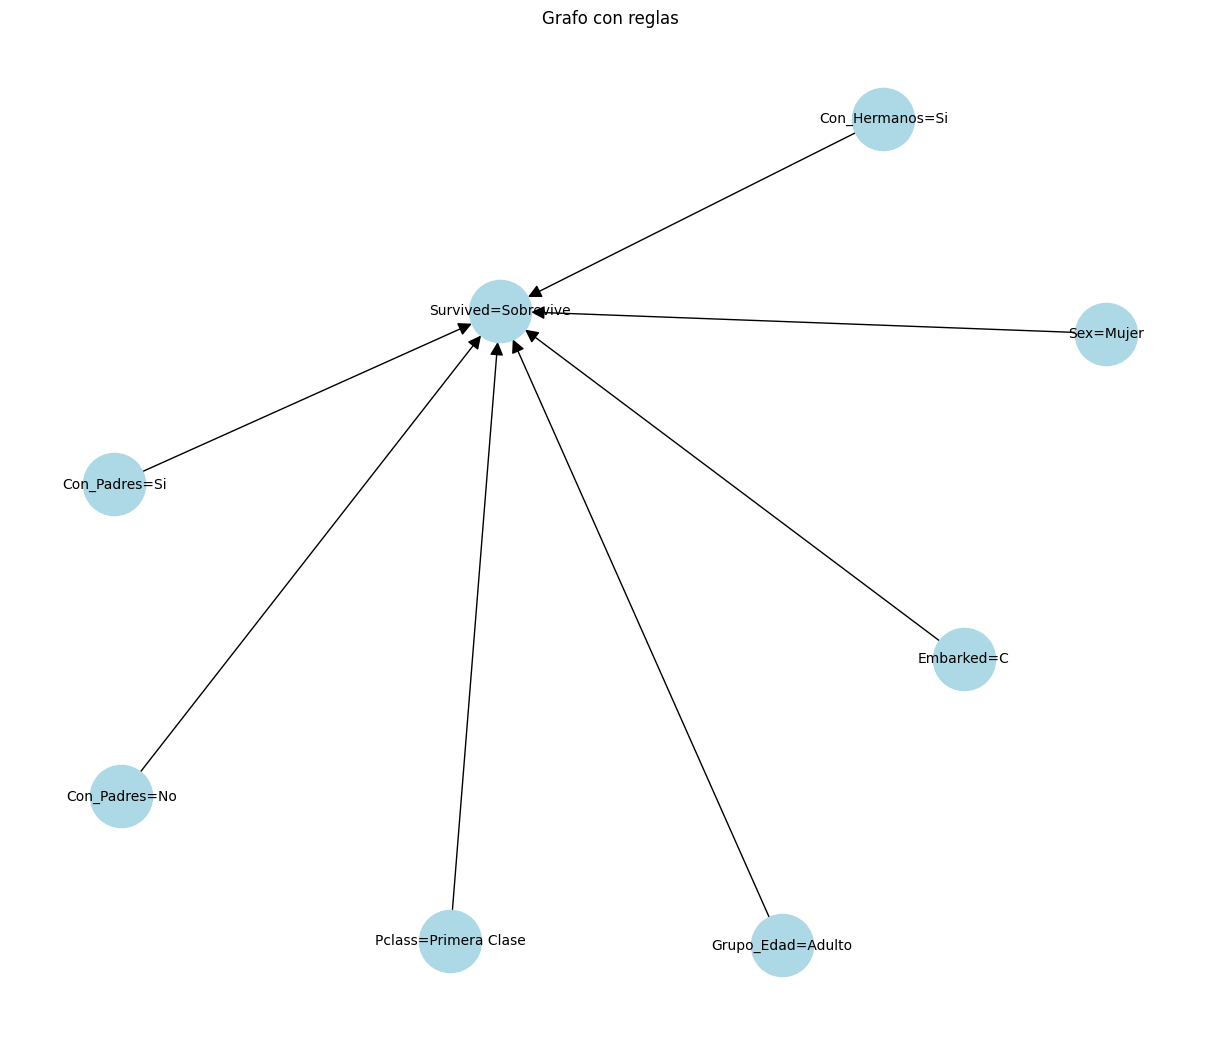

In [110]:
import networkx as nx

G = nx.DiGraph()

for _, row in r4.iterrows():
    for ant in row["antecedents"]:
        for con in row["consequents"]:
            G.add_edge(ant, con, weight=row["lift"])

pos = nx.spring_layout(G, k=1)
plt.figure(figsize=(12,10))

nx.draw(
    G, pos,
    with_labels=True,
    node_size=2000,
    font_size=10,
    node_color="lightblue",
    arrowsize=20
)
plt.title("Grafo con reglas")
plt.show()

In [111]:
labels = []
sources = []
targets = []
values = []

for _, row in r4.iterrows():

    consecuente = list(row["consequents"])[0]

    # crear nodo del consecuente
    if consecuente not in labels:
        labels.append(consecuente)

    for antecedente in row["antecedents"]:

        # crear nodo antecedente
        if antecedente not in labels:
            labels.append(antecedente)

        sources.append(labels.index(antecedente))
        targets.append(labels.index(consecuente))

        # usar soporte como peso
        values.append(row["support"] * 100)


fig = go.Figure(
    data=[
        go.Sankey(
            node=dict(
                label=labels,
                pad=20,
                thickness=20
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values
            )
        )
    ]
)

fig.update_layout(
    title_text="Reglas de asociación - Titanic",
    font_size=12
)


fig.show()

Como se sabe, muchos de los sobrevivientes en el Titanic fueron mujeres. En el grafico de 'grafos' y 'sankey' podemos ver como las reglas de asociación encontradas mediante 'Apriori' con 2% de soporte y un 90% de confianza minima.  
Estas reglas indican que las mujeres con hermanos que embarcaron en C, de primera clase, dentro del grupo adulto y que viajaron o no con padres, presentan una asociación fuerte con la sobrevivencia. 

El grafico 'scatterplot' no mostro mucha información ya que los lift fueron iguales para las mismas 4 reglas, provocando que los puntos se alinearan. 